# Import Libraries

In [24]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import re
import stat

from PIL import Image
print("All Libraries Loaded")

All Libraries Loaded


# Dataset Path

In [2]:
DATASET_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET"
print("Dataset Loaded")

Dataset Loaded


# Class Labels checking

In [11]:
classes = sorted(os.listdir(os.path.join(DATASET_PATH, "classification/train")))
print(f"Classification Dataset Train Classes  {classes}")
classes1 = sorted(os.listdir(os.path.join(DATASET_PATH,"classification/test")))
print(f"Classification Dataset Test Classes  {classes1}")

Classification Dataset Train Classes  ['glioma', 'meningioma', 'pituitary']
Classification Dataset Test Classes  ['glioma', 'meningioma', 'pituitary']


# Count Images

In [13]:
train_count = {}
test_count = {}

for cls in classes:

    train_folder = os.path.join(DATASET_PATH, "Classification/train", cls)
    test_folder = os.path.join(DATASET_PATH, "Classification/test", cls)

    train_count[cls] = len(os.listdir(train_folder))
    test_count[cls] = len(os.listdir(test_folder))

df = pd.DataFrame({
    "Train": train_count,
    "Test": test_count
})

# Total images for each class
df["Total"] = df["Train"] + df["Test"]

print("\nTotal Training Images =", df["Train"].sum())
print("Total Testing Images  =", df["Test"].sum())
print("Total Images          =", df["Total"].sum())

df


Total Training Images = 3933
Total Testing Images  = 860
Total Images          = 4793


,Train,Test,Total
glioma,1147,254,1401
meningioma,1329,306,1635
pituitary,1457,300,1757


# Visualize dataset distribution 

Dataset Distribution
            Train  Test  Total
glioma       1147   254   1401
meningioma   1329   306   1635
pituitary    1457   300   1757

Total Training Images: 3933
Total Testing Images : 860
Total Images         : 4793


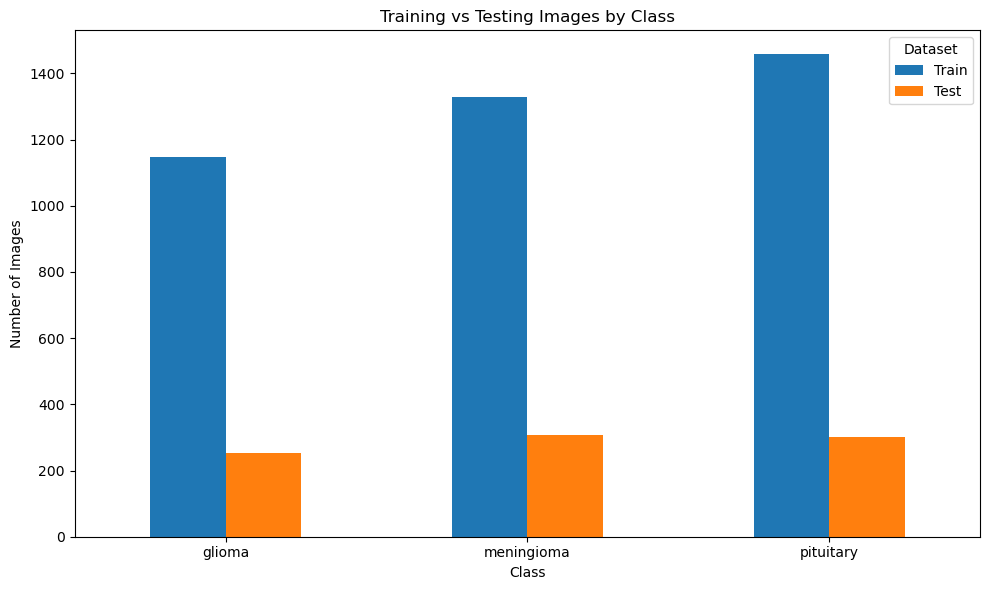

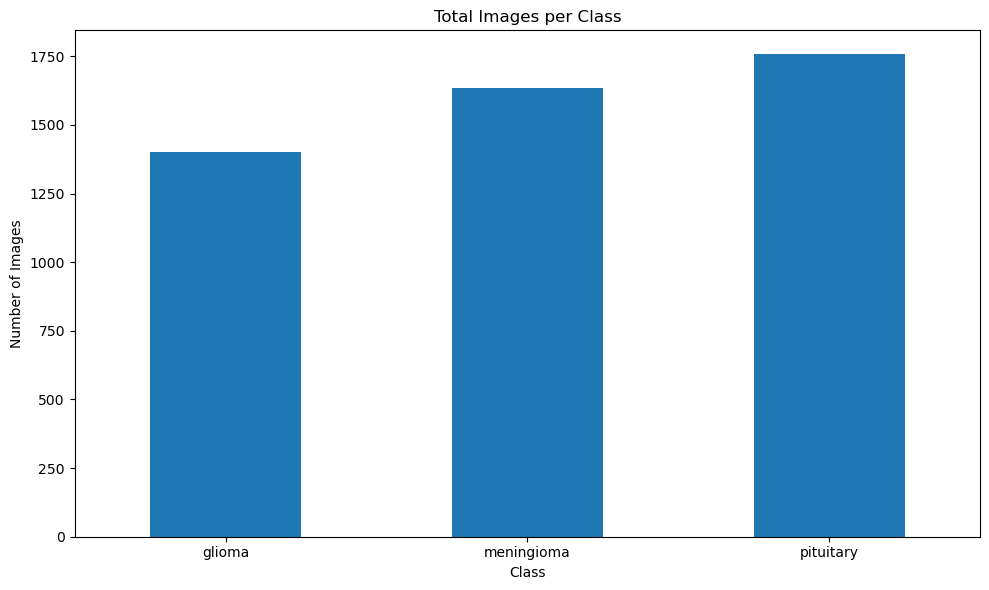

In [18]:
train_path = os.path.join(DATASET_PATH, "classification/train")
test_path = os.path.join(DATASET_PATH, "classification/test")

# Get class names
classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

# Count images
train_count = {}
test_count = {}

for cls in classes:
    train_folder = os.path.join(train_path, cls)
    test_folder = os.path.join(test_path, cls)

    train_count[cls] = len(os.listdir(train_folder))
    test_count[cls] = len(os.listdir(test_folder))

# Create DataFrame
df = pd.DataFrame({
    "Train": train_count,
    "Test": test_count
})

df["Total"] = df["Train"] + df["Test"]

# Print counts
print("Dataset Distribution")
print(df)

print("\nTotal Training Images:", df["Train"].sum())
print("Total Testing Images :", df["Test"].sum())
print("Total Images         :", df["Total"].sum())


# =========================================================
# 1. TRAIN vs TEST BAR GRAPH
# =========================================================

df[["Train", "Test"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Training vs Testing Images by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()


# =========================================================
# 2. TOTAL IMAGES PER CLASS
# =========================================================

df["Total"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Total Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



# Display Random Image

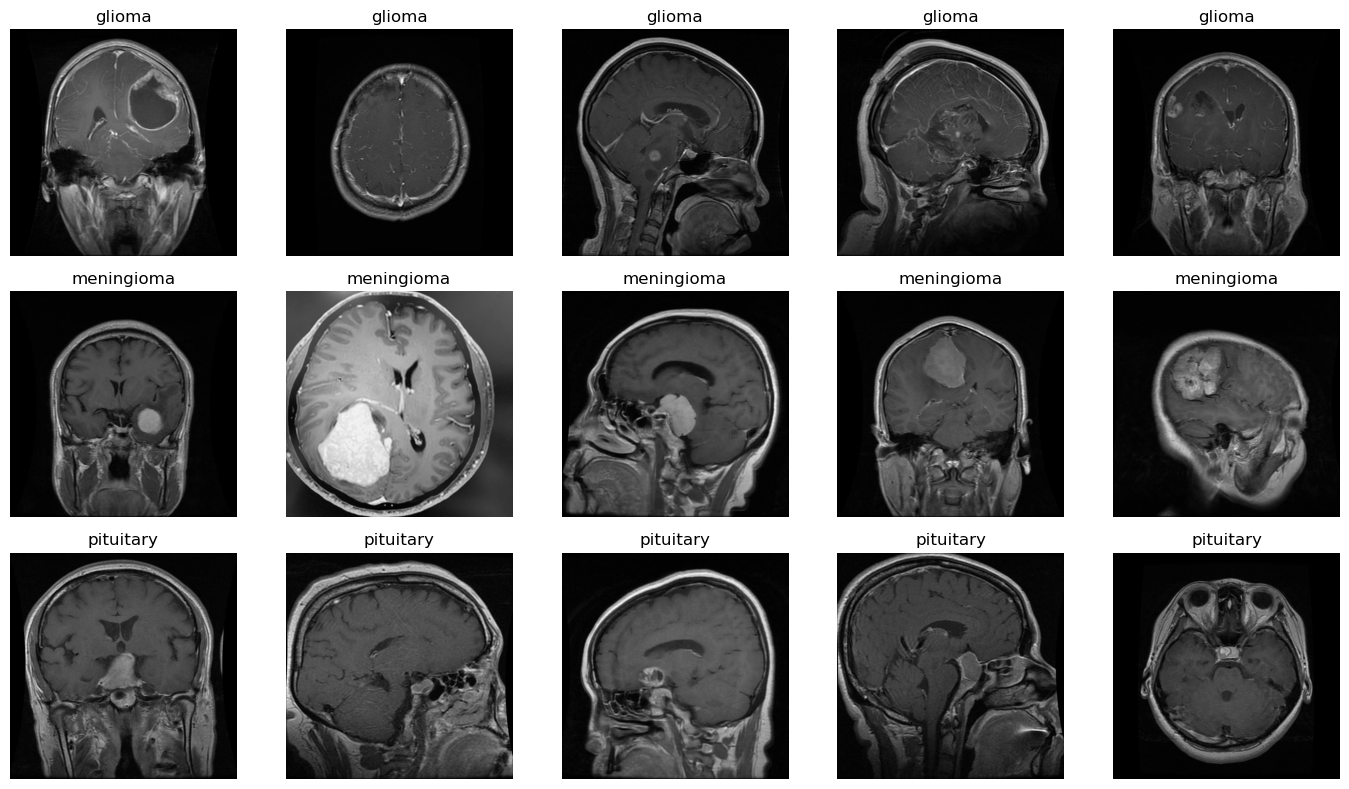

In [19]:
fig, axes = plt.subplots(3,5, figsize=(14,8))

for row, cls in enumerate(classes):

    folder = os.path.join(DATASET_PATH, "classification/train", cls)

    images = random.sample(os.listdir(folder),5)

    for col, img_name in enumerate(images):

        img = cv2.imread(os.path.join(folder,img_name))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        axes[row,col].imshow(img)
        axes[row,col].set_title(cls)

        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

# Image Resulution 

In [20]:
sizes = []

for cls in classes:

    folder = os.path.join(DATASET_PATH,"classification/train",cls)

    for img_name in os.listdir(folder):

        img = Image.open(os.path.join(folder,img_name))

        sizes.append(img.size)

size_df = pd.DataFrame(sizes,columns=["Width","Height"])

size_df.head()

,Width,Height
0,512,512
1,512,512
2,512,512
3,512,512
4,512,512


# Check Duplicate Names

In [21]:
all_names = []

for cls in classes:

    folder = os.path.join(DATASET_PATH,"classification/train",cls)

    all_names.extend(os.listdir(folder))

print("Duplicate Names :",len(all_names)-len(set(all_names)))

Duplicate Names : 0


# dataset distribution image generate 

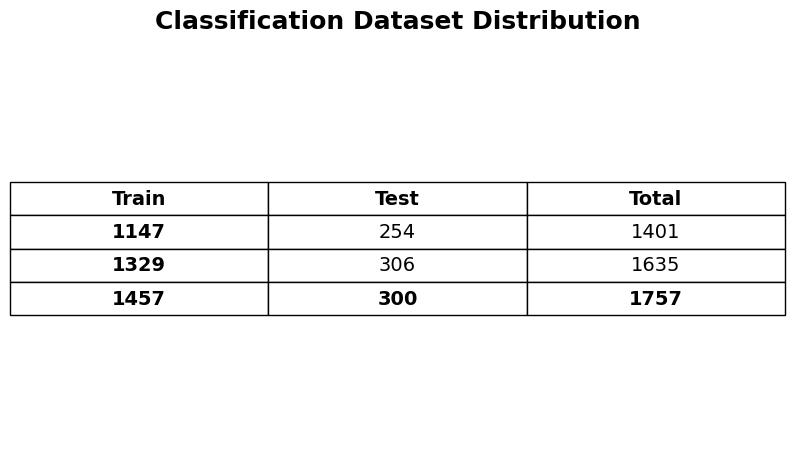

In [23]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

ax.axis("off")

# Create table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center"
)

# Font settings
table.auto_set_font_size(False)
table.set_fontsize(14)

# Increase row height
table.scale(1, 2)

# -------------------------
# Format header
# -------------------------

for col in range(len(df.columns)):
    table[0, col].set_text_props(weight="bold")

# -------------------------
# Format first column
# -------------------------

for row in range(1, len(df) + 1):
    table[row, 0].set_text_props(weight="bold")

# -------------------------
# Format Total row
# -------------------------

total_row = len(df)

for col in range(len(df.columns)):
    table[total_row, col].set_text_props(weight="bold")

# -------------------------
# Title
# -------------------------

plt.title(
    "Classification Dataset Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# -------------------------
# Save table as image
# -------------------------

plt.savefig(
    "classification_dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Image Dimension channel checking

In [1]:
import cv2

image_path = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification\train\pituitary\pituitary_train_74_ax_t1.jpg"
img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

if img is None:
    print("Could not read image.")
else:
    print("Shape:", img.shape)

    if len(img.shape) == 2:
        print("Channels: 1 (Grayscale)")
    elif len(img.shape) == 3:
        print("Channels:", img.shape[2])

        if img.shape[2] == 3:
            print("Type: 3-channel BGR/RGB image")
        elif img.shape[2] == 4:
            print("Type: 4-channel BGRA/RGBA image")

Shape: (512, 512, 3)
Channels: 3
Type: 3-channel BGR/RGB image
